In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, datasets, transforms
from torch.utils.data import DataLoader, Subset
from PIL import Image
import matplotlib.pyplot as plt
import adom_library as adom

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(DEVICE)

cuda


# VGG16 vs AlexNet vs GoogleNet

## Trenowanie modeli z różną liczbą epok

In [2]:
import time

dataset = adom.get_CIFAR10_dataset()
classes = dataset.classes

model_vgg16 = None
model_alexnet = None
model_googlenet = None

def format_time(seconds):
    m = int(seconds // 60)
    s = int(seconds % 60)
    return f"{m}m {s}s"

def train(num_epochs):
    global model_vgg16, model_alexnet, model_googlenet
    
    print("Training VGG16:")
    start = time.time()
    model_vgg16 = adom.train_new_model(
        dataset,
        model_type="VGG16",
        epochs=num_epochs
    )
    end = time.time()
    print(f"VGG16 training time: {format_time(end - start)}")

    print("\nTraining AlexNet:")
    start = time.time()
    model_alexnet = adom.train_new_model(
        dataset,
        model_type="AlexNet",
        epochs=num_epochs
    )
    end = time.time()
    print(f"AlexNet training time: {format_time(end - start)}")

    print("\nTraining GoogleNet:")
    start = time.time()
    model_googlenet = adom.train_new_model(
        dataset,
        model_type="GoogleNet",
        epochs=num_epochs
    )
    end = time.time()
    print(f"GoogleNet training time: {format_time(end - start)}")
    
    print("VGG16 params:", adom.count_model_params(model_vgg16))
    print("AlexNet params:", adom.count_model_params(model_alexnet))
    print("GoogleNet params:", adom.count_model_params(model_googlenet))

def evaluate(img_path="tygrys.jpg"):
    print("=== VGG16 ===")
    adom.classify_image_with_model(model=model_vgg16, classes=classes, image_path=img_path)

    print("\n=== AlexNet ===")
    adom.classify_image_with_model(model=model_alexnet, classes=classes, image_path=img_path)

    print("\n=== GoogleNet ===")
    adom.classify_image_with_model(model=model_googlenet, classes=classes, image_path=img_path)

Files already downloaded and verified


d:\Projekty\Studia\ADOM\ADOM_2026L_Deep_CNN-VGG\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [3]:
train(num_epochs=1)

Training VGG16:
Epoch 1, Loss: 1.5171, Acc: 44.38%
VGG16 training time: 5m 7s

Training AlexNet:
Epoch 1, Loss: 1.4151, Acc: 48.03%
AlexNet training time: 1m 30s

Training GoogleNet:


d:\Projekty\Studia\ADOM\ADOM_2026L_Deep_CNN-VGG\.venv\Lib\site-packages\torchvision\models\googlenet.py:47: FutureWarning: The default weight initialization of GoogleNet will be changed in future releases of torchvision. If you wish to keep the old behavior (which leads to long initialization times due to scipy/scipy#11299), please set init_weights=True.
  warnings.warn(


Epoch 1, Loss: 1.3079, Acc: 53.23%
GoogleNet training time: 2m 7s
VGG16 params: 134301514
AlexNet params: 57044810
GoogleNet params: 5610154


=== VGG16 ===
truck 53.82 %
cat 10.82 %
horse 7.07 %
automobile 5.55 %
bird 5.22 %

=== AlexNet ===
frog 81.34 %
cat 9.33 %
truck 4.66 %
bird 1.7 %
dog 1.51 %

=== GoogleNet ===
deer 33.76 %
frog 31.14 %
airplane 13.64 %
horse 8.58 %
bird 7.3 %


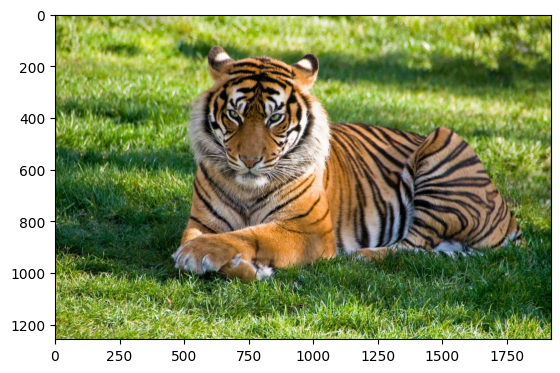

In [10]:
evaluate()

=== VGG16 ===
horse 95.27 %
deer 4.53 %
dog 0.1 %
bird 0.06 %
airplane 0.02 %

=== AlexNet ===
horse 82.11 %
deer 17.73 %
dog 0.11 %
bird 0.02 %
cat 0.01 %

=== GoogleNet ===
horse 59.38 %
deer 37.74 %
frog 0.98 %
bird 0.72 %
airplane 0.71 %


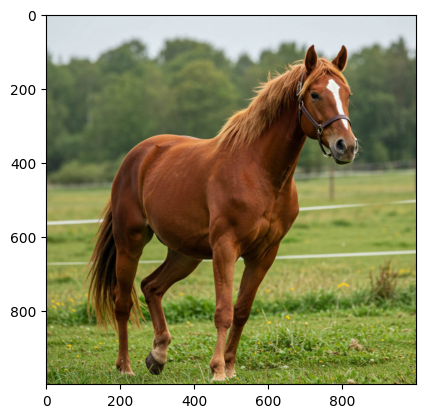

In [11]:
evaluate(img_path="kon.jpg")

In [12]:
train(num_epochs=2)

Training VGG16:
Epoch 1, Loss: 1.4837, Acc: 45.49%
Epoch 2, Loss: 0.8491, Acc: 70.27%
VGG16 training time: 11m 15s

Training AlexNet:
Epoch 1, Loss: 1.4098, Acc: 48.47%
Epoch 2, Loss: 0.9214, Acc: 67.72%
AlexNet training time: 4m 13s

Training GoogleNet:
Epoch 1, Loss: 1.3043, Acc: 52.99%
Epoch 2, Loss: 0.8388, Acc: 71.11%
GoogleNet training time: 4m 9s
VGG16 params: 134301514
AlexNet params: 57044810
GoogleNet params: 5610154


=== VGG16 ===
horse 42.12 %
truck 25.21 %
cat 16.2 %
dog 7.01 %
deer 3.36 %

=== AlexNet ===
frog 42.09 %
cat 23.58 %
truck 16.38 %
dog 4.69 %
automobile 3.04 %

=== GoogleNet ===
bird 41.05 %
horse 15.73 %
cat 14.28 %
deer 12.03 %
frog 6.38 %


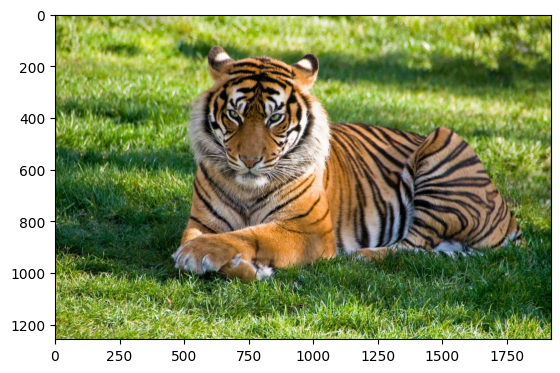

In [13]:
evaluate()

=== VGG16 ===
horse 99.42 %
deer 0.53 %
dog 0.05 %
cat 0.0 %
bird 0.0 %

=== AlexNet ===
horse 99.27 %
deer 0.33 %
dog 0.28 %
airplane 0.04 %
bird 0.04 %

=== GoogleNet ===
horse 99.98 %
deer 0.02 %
dog 0.0 %
airplane 0.0 %
cat 0.0 %


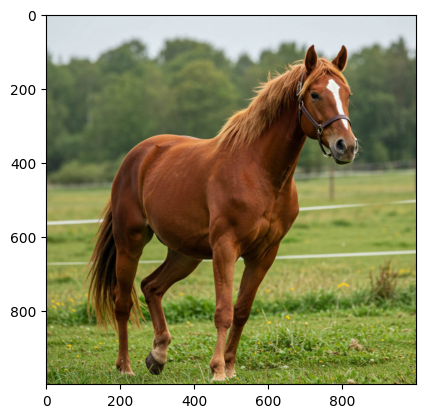

In [15]:
evaluate(img_path="kon.jpg")